In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
df = pd.read_csv(r'C:\Users\User\Downloads\data.csv', encoding='ISO-8859-1')

print("Shape:", df.shape)
df.info()

Shape: (541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [7]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['is_cancelled'] = df['InvoiceNo'].astype(str).str.startswith('C')

cancelled_orders = df[df['is_cancelled']]
print(f"Total cancelled order rows: {len(cancelled_orders):,}")
print(f"Total unique cancelled invoices: {cancelled_orders['InvoiceNo'].nunique():,}")
cancelled_orders.head()

Total cancelled order rows: 9,288
Total unique cancelled invoices: 3,836


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,True
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,True
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,True
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,True
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,True


In [8]:
rows_before = len(df)
df_clean = df.dropna(subset=['CustomerID']).copy()
rows_after = len(df_clean)

print(f"Rows before: {rows_before:,}")
print(f"Rows after dropping missing CustomerID: {rows_after:,}")
print(f"Rows dropped: {rows_before - rows_after:,}")

Rows before: 541,909
Rows after dropping missing CustomerID: 406,829
Rows dropped: 135,080


In [9]:
returns_df = df_clean[df_clean['Quantity'] < 0]
print(f"Rows with negative quantity (returns): {len(returns_df):,}")

# Keep only positive-quantity transactions for revenue analysis
sales_df = df_clean[df_clean['Quantity'] > 0].copy()
print(f"Rows remaining for revenue analysis: {len(sales_df):,}")

Rows with negative quantity (returns): 8,905
Rows remaining for revenue analysis: 397,924


In [10]:
sales_df['Revenue'] = sales_df['Quantity'] * sales_df['UnitPrice']

print(f"Total revenue: £{sales_df['Revenue'].sum():,.2f}")

Total revenue: £8,911,407.90


In [11]:
customer_agg = sales_df.groupby('CustomerID').agg(
    total_revenue=('Revenue', 'sum'),
    total_orders=('InvoiceNo', 'nunique')
)
customer_agg['avg_order_value'] = (customer_agg['total_revenue'] / customer_agg['total_orders']).round(2)
customer_agg = customer_agg.sort_values('total_revenue', ascending=False)

print(f"Number of unique customers: {len(customer_agg):,}")
print(f"Average order value across all customers: £{customer_agg['avg_order_value'].mean():.2f}")
customer_agg.head(10)

Number of unique customers: 4,339
Average order value across all customers: £419.05


,total_revenue,total_orders,avg_order_value
CustomerID,,,
14646.0,280206.02,74,3786.57
18102.0,259657.30,60,4327.62
17450.0,194550.79,46,4229.36
16446.0,168472.50,2,84236.25
14911.0,143825.06,201,715.55
12415.0,124914.53,21,5948.31
14156.0,117379.63,55,2134.18
17511.0,91062.38,31,2937.50
16029.0,81024.84,63,1286.11


In [12]:
top5_share = customer_agg.head(5)['total_revenue'].sum() / customer_agg['total_revenue'].sum() * 100
print(f"Top 5 customers account for {top5_share:.2f}% of total revenue")

Top 5 customers account for 11.75% of total revenue


In [13]:
country_agg = sales_df.groupby('Country').agg(
    total_revenue=('Revenue', 'sum'),
    total_orders=('InvoiceNo', 'nunique')
).sort_values('total_revenue', ascending=False)

country_agg['revenue_share_%'] = (country_agg['total_revenue'] / country_agg['total_revenue'].sum() * 100).round(2)
country_agg.head(10)

,total_revenue,total_orders,revenue_share_%
Country,,,
United Kingdom,7308391.554,16649,82.01
Netherlands,285446.340,95,3.20
EIRE,265545.900,260,2.98
Germany,228867.140,457,2.57
France,209024.050,389,2.35
Australia,138521.310,57,1.55
Spain,61577.110,90,0.69
Switzerland,56443.950,51,0.63
Belgium,41196.340,98,0.46


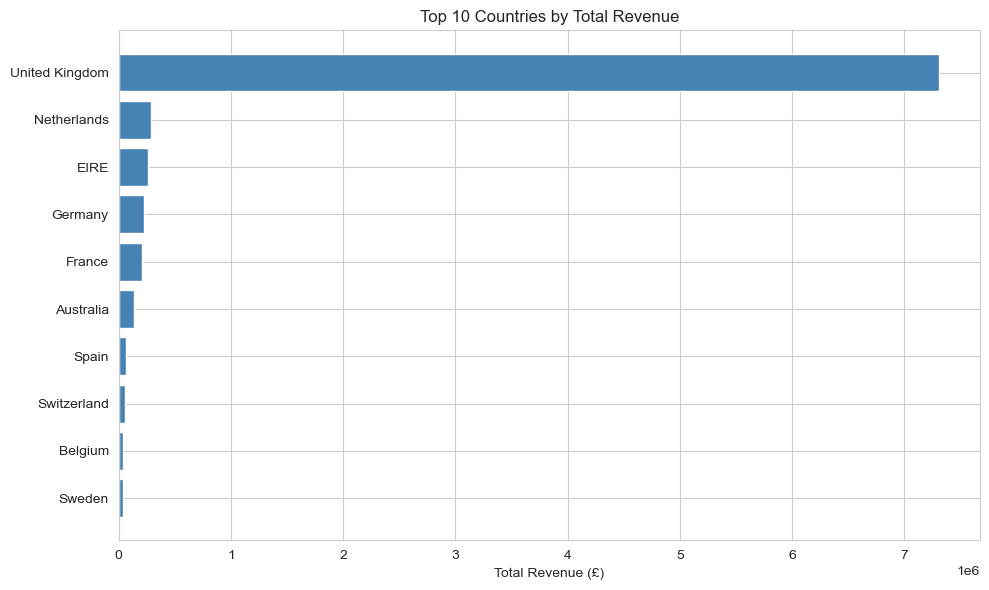

In [14]:
top10_countries = country_agg.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10_countries.index[::-1], top10_countries['total_revenue'][::-1], color='steelblue')
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Total Revenue (£)')
plt.tight_layout()
plt.show()

In [15]:
sales_df['Month'] = sales_df['InvoiceDate'].dt.to_period('M')
monthly_revenue = sales_df.groupby('Month')['Revenue'].sum()
monthly_revenue

Month
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: Revenue, dtype: float64

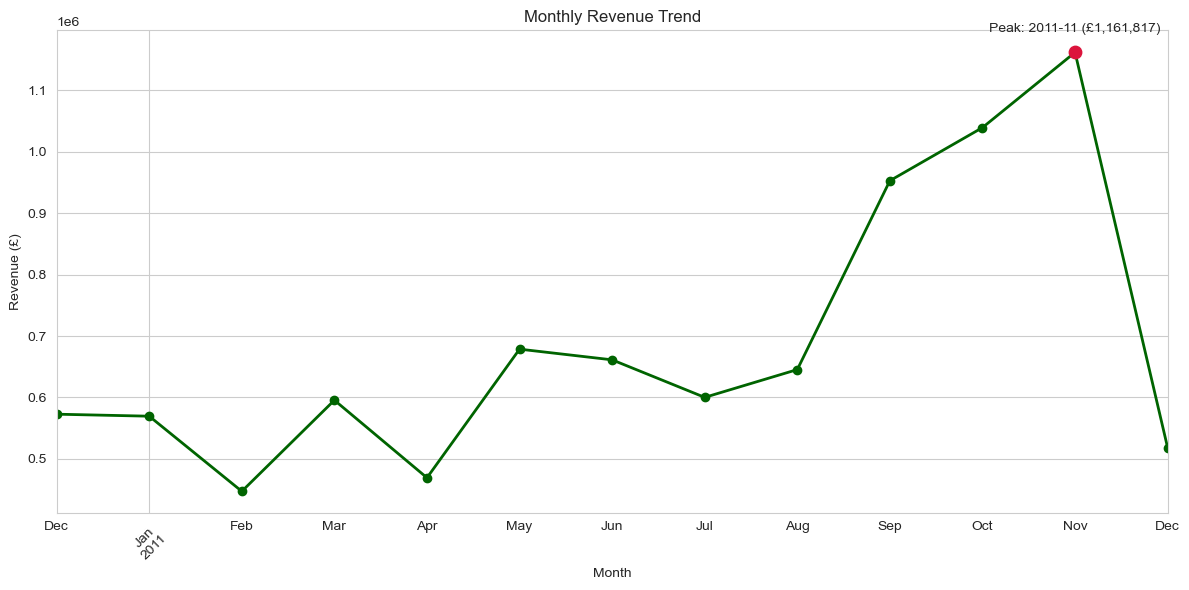

Peak month: 2011-11 with £1,161,817.38


In [16]:
plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', marker='o', linewidth=2, color='darkgreen')
peak_month = monthly_revenue.idxmax()
plt.scatter([peak_month], [monthly_revenue.max()], color='crimson', zorder=5, s=80)
plt.annotate(f"Peak: {peak_month} (£{monthly_revenue.max():,.0f})",
             (peak_month, monthly_revenue.max()), textcoords="offset points", xytext=(0, 15), ha='center')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Peak month: {peak_month} with £{monthly_revenue.max():,.2f}")

In [17]:
top20_products = sales_df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(20)
top20_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
PACK OF 12 LONDON TISSUES             25345
PACK OF 60 PINK PAISLEY CAKE CASES    24264
BROCADE RING PURSE                    22963
VICTORIAN GLASS HANGING T-LIGHT       22433
ASSORTED COLOURS SILK FAN             21876
RED  HARMONICA IN BOX                 20975
JUMBO BAG PINK POLKADOT               20165
SMALL POPCORN HOLDER                  18252
LUNCH BAG RED RETROSPOT               17697
60 TEATIME FAIRY CAKE CASES           17689
Name: Quantity, dtype: int64

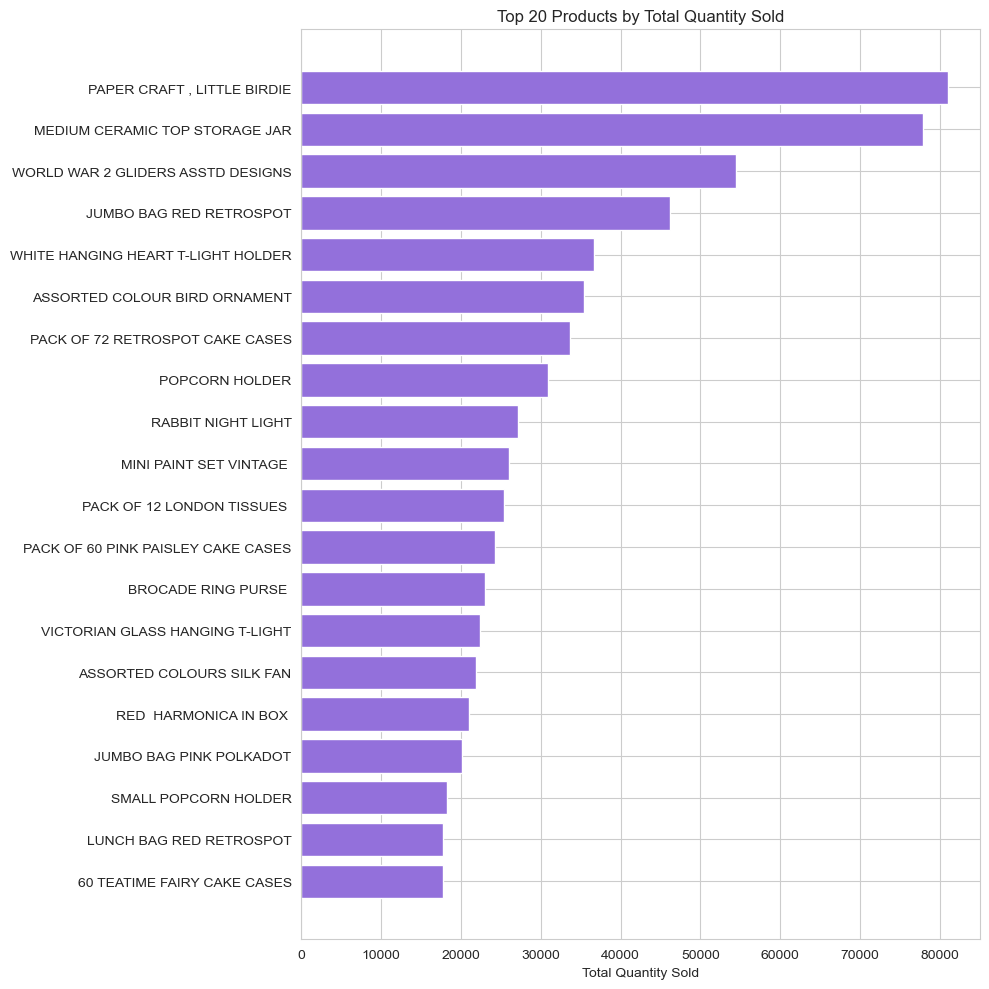

In [18]:
plt.figure(figsize=(10, 10))
plt.barh(top20_products.index[::-1], top20_products.values[::-1], color='mediumpurple')
plt.title('Top 20 Products by Total Quantity Sold')
plt.xlabel('Total Quantity Sold')
plt.tight_layout()
plt.show()

In [19]:
orders_per_country = df_clean.groupby('Country')['InvoiceNo'].nunique()
cancelled_per_country = df_clean[df_clean['is_cancelled']].groupby('Country')['InvoiceNo'].nunique()

return_rate = (cancelled_per_country / orders_per_country * 100).fillna(0).sort_values(ascending=False)
return_rate_df = pd.DataFrame({
    'total_orders': orders_per_country,
    'cancelled_orders': cancelled_per_country.reindex(orders_per_country.index).fillna(0).astype(int),
    'return_rate_%': return_rate.reindex(orders_per_country.index).fillna(0).round(2)
}).sort_values('return_rate_%', ascending=False)

return_rate_df.head(15)

,total_orders,cancelled_orders,return_rate_%
Country,,,
Czech Republic,5,3,60.00
Saudi Arabia,2,1,50.00
Malta,10,5,50.00
Japan,28,9,32.14
Italy,55,17,30.91
Singapore,10,3,30.00
USA,7,2,28.57
Switzerland,71,20,28.17
Germany,603,146,24.21


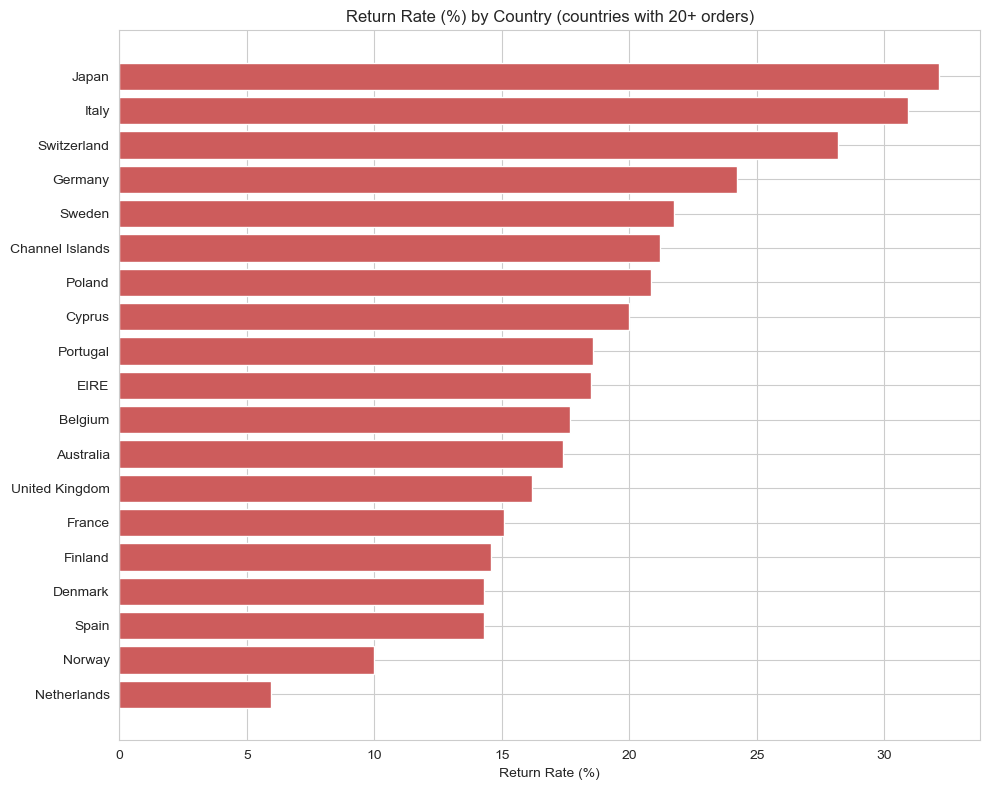

In [20]:
# Only show countries with a meaningful number of orders for a fair comparison
meaningful = return_rate_df[return_rate_df['total_orders'] >= 20].sort_values('return_rate_%', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(meaningful.index[::-1], meaningful['return_rate_%'][::-1], color='indianred')
plt.title('Return Rate (%) by Country (countries with 20+ orders)')
plt.xlabel('Return Rate (%)')
plt.tight_layout()
plt.show()

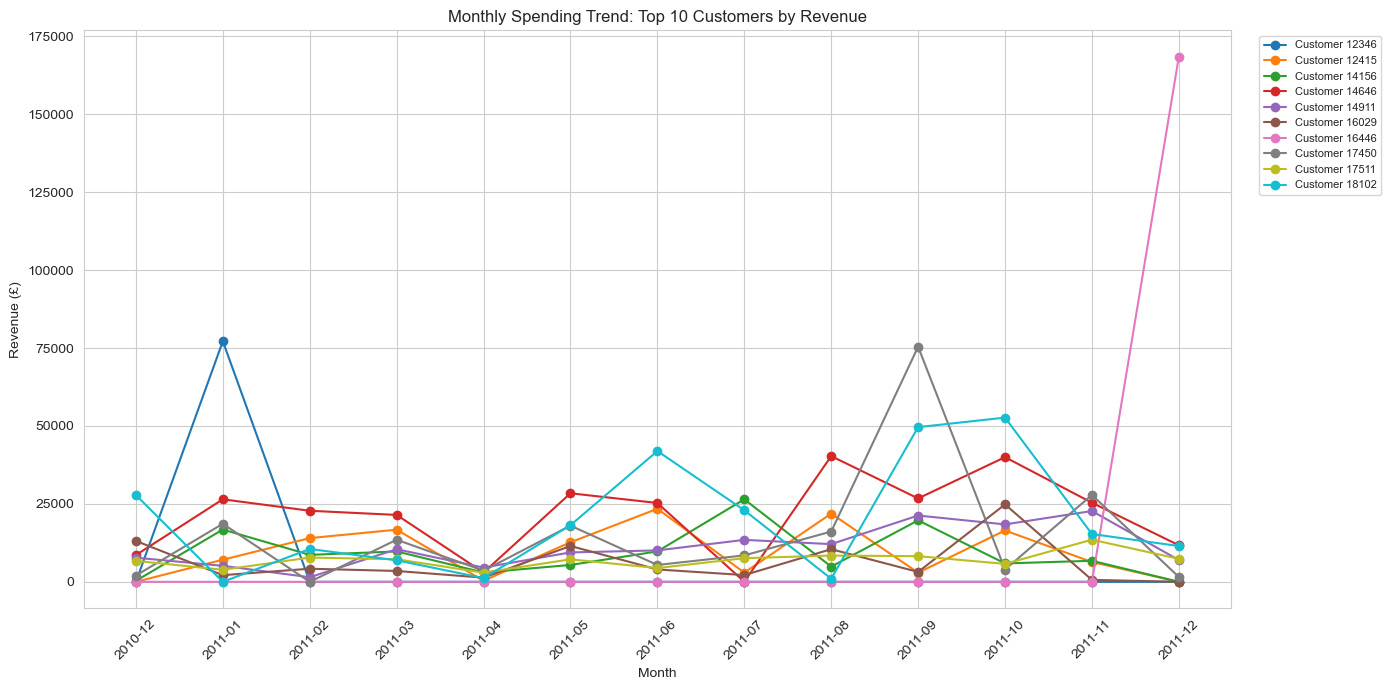

In [21]:
top10_customer_ids = customer_agg.head(10).index

top10_monthly = sales_df[sales_df['CustomerID'].isin(top10_customer_ids)].groupby(
    ['CustomerID', 'Month'])['Revenue'].sum().unstack(fill_value=0)

plt.figure(figsize=(14, 7))
for cust_id in top10_monthly.index:
    plt.plot(top10_monthly.columns.astype(str), top10_monthly.loc[cust_id], marker='o', label=f"Customer {int(cust_id)}")
plt.title('Monthly Spending Trend: Top 10 Customers by Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [22]:
basket_size = sales_df.groupby(['Country', 'InvoiceNo'])['StockCode'].nunique().reset_index()
basket_size_by_country = basket_size.groupby('Country')['StockCode'].mean().sort_values(ascending=False)

basket_size_by_country.head(15)

Country
RSA                58.000000
Israel             49.000000
Lebanon            45.000000
Cyprus             37.437500
Switzerland        36.098039
USA                35.800000
Brazil             32.000000
Singapore          31.142857
Unspecified        29.875000
Norway             29.694444
Greece             29.000000
Channel Islands    28.730769
EIRE               27.792308
Spain              27.377778
Iceland            26.000000
Name: StockCode, dtype: float64

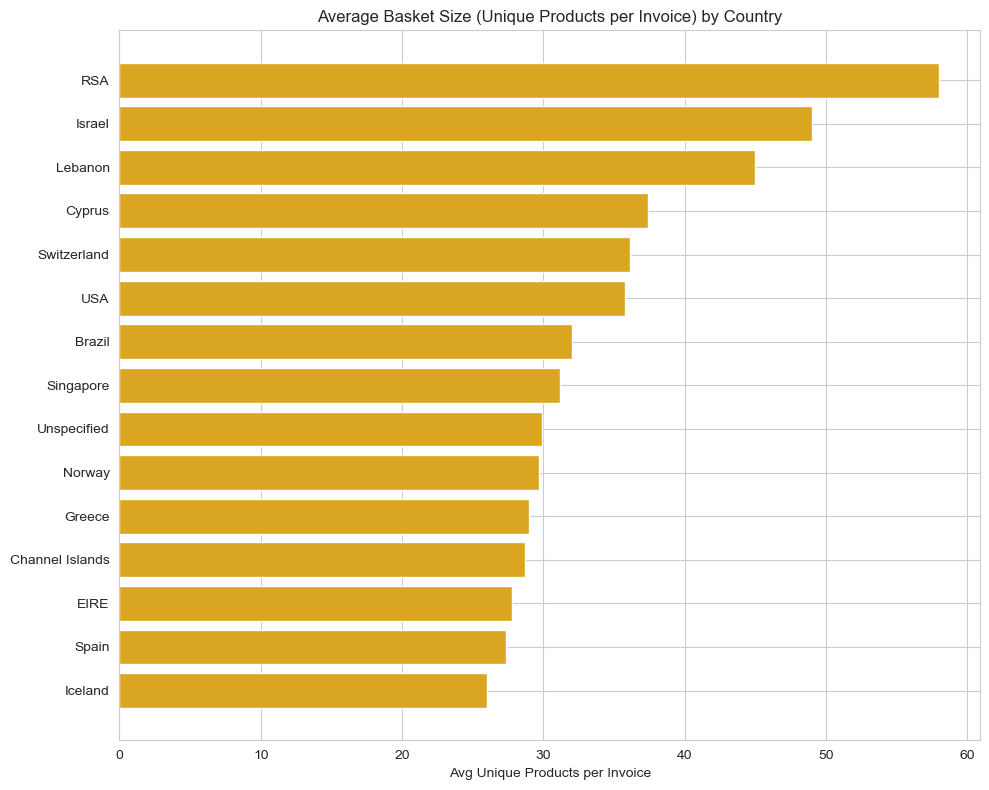

In [23]:
plt.figure(figsize=(10, 8))
top15_basket = basket_size_by_country.head(15)
plt.barh(top15_basket.index[::-1], top15_basket.values[::-1], color='goldenrod')
plt.title('Average Basket Size (Unique Products per Invoice) by Country')
plt.xlabel('Avg Unique Products per Invoice')
plt.tight_layout()
plt.show()